In [2]:
import pandas as pd 
import seaborn as sns

In [3]:
df=pd.read_csv('../../../data/processed/DNA/Merged_HRD.csv', index_col=0)

In [4]:
topics=pd.read_excel('../../../data/processed/clinical/Subjects_data.xlsx', index_col=0)

In [5]:
topics['subject_id']=['HDM-'+str(i) for i in topics.index.values]

In [6]:
df=df.merge(topics, left_on='subject_id', right_on='subject_id', how='left')

In [7]:
df=df.rename(columns={'Hyper_DCABP_general':'DCABP'})

In [8]:
df.loc[df.DCABP==0,'DCABP']='U-DCABP'
df.loc[df.DCABP==1,'DCABP']='F-DCABP'

/var/folders/nm/zjh2_fld07sfnhxsrc8fykv0ply609/T/ipykernel_3237/2184439140.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'U-DCABP' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df.DCABP==0,'DCABP']='U-DCABP'


In [9]:
df=df.sort_values('DCABP', ascending=False)

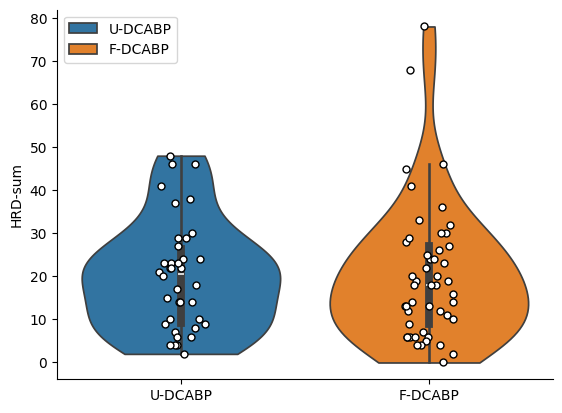

In [10]:
import matplotlib.pyplot as plt
sns.violinplot(df, y='HRD-sum', x='DCABP', hue='DCABP',cut=0)
sns.stripplot(df, y='HRD-sum', x='DCABP', color='w', edgecolor='k', linewidth=1)
plt.xlabel('')
sns.despine()
#plt.savefig('HRD.svg')

In [11]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(df[df.DCABP=='F-DCABP']['HRD-sum'].values, df[df.DCABP=='U-DCABP']['HRD-sum'].values, alternative='two-sided')

In [12]:
p


0.7158496321335195